In [2]:

import numpy as np
#%pip install torch tqdm
import torch
from torch import nn
import tqdm

In [6]:
%pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 234.5 kB/s eta 0:00:17
   ---- ----------------------------------- 0.5/4.3 MB 234.5 kB/s eta 0:00:17
   ---- ----------------------------------- 0.5/4.3 MB 234.5 kB/s eta 0:00:17
   ----

In [3]:
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

844
94
40


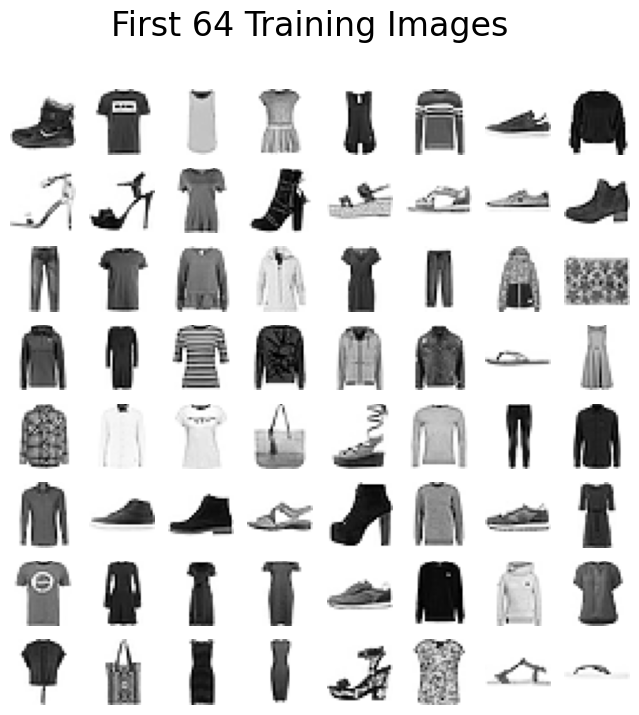

In [4]:
# Use the following code to load and normalize the dataset for training and testing
# It will downlad the dataset into data subfolder (change to your data folder name)
train_dataset = torchvision.datasets.FashionMNIST('data/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))

test_dataset = torchvision.datasets.FashionMNIST('data/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.2860,), (0.3530,))
                             ]))


# Use the following code to create a validation set of 10%
train_indices, val_indices, _, _ = train_test_split(
    range(len(train_dataset)),
    train_dataset.targets,
    stratify=train_dataset.targets,
    test_size=0.1,
)

# Generate training and validation subsets based on indices
train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)


# set batches sizes
train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)

train_batch_size = 64

# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)


print(num_train_batches)
print(num_val_batches)
print(num_test_batches)


#Sample code to visulaize the first sample in first 16 batches 

# batch_num = 0
# for train_features, train_labels in train_batches:
    
#     if batch_num == 16:
#         break    # break here
    
#     batch_num = batch_num +1
#     print(f"Feature batch shape: {train_features.size()}")
#     print(f"Labels batch shape: {train_labels.size()}")
    
#     img = train_features[0].squeeze()
#     label = train_labels[0]
#     plt.imshow(img, cmap="gray")
#     plt.show()
#     print(f"Label: {label}")



# Sample code to plot N^2 images from the dataset
def plot_images(XX, N, title):
    fig, ax = plt.subplots(N, N, figsize=(8, 8))
  
    for i in range(N):
      for j in range(N):
        ax[i,j].imshow(XX[(N)*i+j], cmap="Greys")
        ax[i,j].axis("off")
    fig.suptitle(title, fontsize=24)

plot_images(train_dataset.data[:64], 8, "First 64 Training Images" )

    

In [ ]:
#Define your (As Cool As It Gets) Fully Connected Neural Network 
class Network(nn.Module):
    #Initialize model layers, add additional arguments to adjust
    def __init__(self, input_dim, output_dim): 
        super(Network, self).__init__()

        
        self.fc1 = nn.Linear(input_dim, input_dim)
        self.bn1 = nn.BatchNorm1d(input_dim) #Define the first batch normalization layer
        self.fc2 = nn.Linear(input_dim, input_dim) #Define the second fully connected layer
        self.bn2 = nn.BatchNorm1d(input_dim) #Define the second batch normalization layer
        self.fc3 = nn.Linear(input_dim, input_dim)
        self.bn3 = nn.BatchNorm1d(input_dim) #Define the third batch normalization layer
        self.fc4 = nn.Linear(input_dim, output_dim) #Define the third fully connected layer
        self.relu = nn.ReLU() #Define the ReLU activation function
        self.apply(self._init_weights) #Initialize the weights of the network using a custom method
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity='relu') 
            nn.init.zeros_(m.bias) #Initialize the biases to zero
        #Define the network layer(s) and activation function(s)
 
    def forward(self, input):
        #Define how your model propagates the input through the network
        x = self.relu(self.fc1(input))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x


In [6]:
import torch.optim as optim

In [12]:
# Initialize neural network model with input, output and hidden layer dimensions
model = Network(input_dim = 784, output_dim = 10) #... add more parameters
                
# Define the learning rate and epochs number
learning_rate = 0.01
epochs = 20


train_loss_list = np.zeros((epochs,))
validation_accuracy_list = np.zeros((epochs,))

# Define loss function  and optimizer
loss_func = nn.CrossEntropyLoss() # Use Cross Entropy loss from torch.nn 
optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Use optimizers from torch.optim
#optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Use optimizers from torch.optim
#optimizer = optim.RMSprop(model.parameters(), lr=learning_rate) # Use optimizers from torch.optim
# Iterate over epochs, batches with progress bar and train+ validate the Network
# Track the loss and validation accuracy
for epoch in tqdm.trange(epochs):

    # Network Training 
    for train_features, train_labels in train_batches:
        # Set model into training mode
        model.train()
        
        # Reshape images into a vector
        train_features = train_features.reshape(-1, 28*28)

        # Reset gradients, Calculate training loss on model 
        loss = loss_func(model(train_features), train_labels)
        optimizer.zero_grad() # Reset gradients
        
        # Perfrom optimization, back propagation
        loss.backward() 
        optimizer.step() 
 
    # Record loss for the epoch
    train_loss_list[epoch] = loss.item()

    val_acc = 0
    total = 0
    # Network Validation
    for val_features, val_labels in val_batches:
        
        # Telling PyTorch we aren't passing inputs to network for training purpose
        with torch.no_grad(): 
            model.eval()

             # Reshape validation images into a vector
            val_features = val_features.reshape(-1, 28*28)
          
            # Compute validation outputs (targets) 
            val_outputs = model(val_features)

            # and compute accuracy 
            test, predicted = torch.max(val_outputs.data, 1)
            total += val_labels.size(0)
            validation_accuracy_list[epoch] += (predicted == val_labels).sum().item()       
    
    # Record accuracy for the epoch; print training loss, validation accuracy
    print("Epoch: "+ str(epoch) +"; Validation Accuracy:" + str(validation_accuracy_list[epoch]/total*100) + '%' + "Training Loss: " + str(train_loss_list[epoch]))
    validation_accuracy_list[epoch] = validation_accuracy_list[epoch]/total*100



  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:45<14:28, 45.72s/it]

Epoch: 0; Validation Accuracy:77.5%Training Loss: 0.8385542035102844


 10%|█         | 2/20 [01:37<14:46, 49.24s/it]

Epoch: 1; Validation Accuracy:81.55%Training Loss: 0.34147176146507263


...

Epoch: 17; Validation Accuracy:88.98333333333333%Training Loss: 0.2714828550815582


 95%|█████████▌| 19/20 [15:49<00:45, 45.20s/it]

Epoch: 18; Validation Accuracy:88.76666666666667%Training Loss: 0.22294680774211884


100%|██████████| 20/20 [16:33<00:00, 49.66s/it]

Epoch: 19; Validation Accuracy:89.26666666666667%Training Loss: 0.3066374361515045


Text(0, 0.5, 'Training Loss')

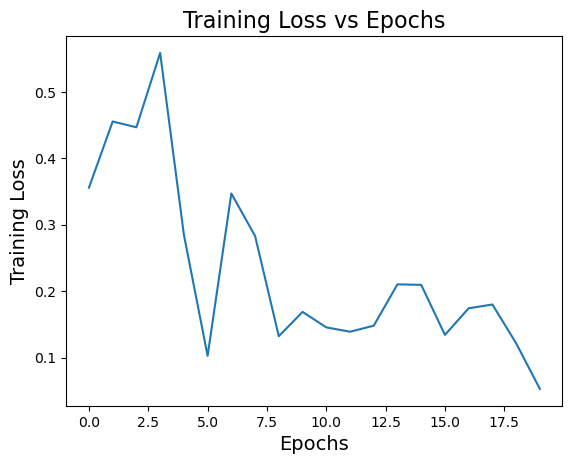

In [8]:
# Plot training loss and validation accuracy throughout the training epochs
plt.plot(train_loss_list, label="Training Loss")
plt.title("Training Loss vs Epochs", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)


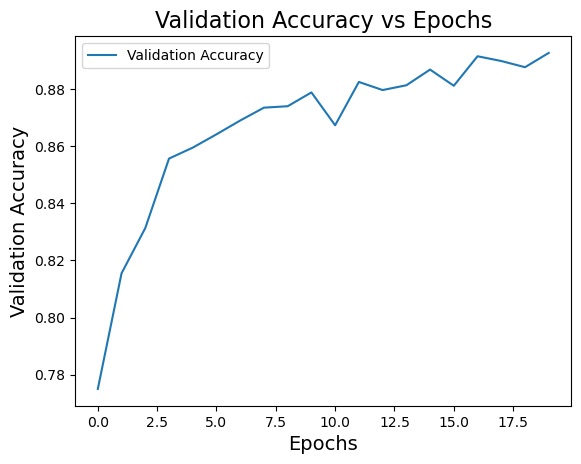

In [13]:
plt.plot(validation_accuracy_list/100, label="Validation Accuracy")
plt.title("Validation Accuracy vs Epochs", fontsize=16)
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Validation Accuracy", fontsize=14)
plt.legend()
plt.show()

In [10]:
#Calculate accuracy on test set

# Telling PyTorch we aren't passing inputs to network for training purpose
with torch.no_grad():
    validation_accuracy = 0
    total = 0

    for test_features, test_labels in test_batches:

        model.eval()
        # Reshape test images into a vector
        test_features = test_features.reshape(-1, 28*28)

         # Compute test outputs (targets) 
        test_outputs = model(test_features)
         # and compute accuracy 
        test, predicted = torch.max(test_outputs.data, 1)
        total += test_labels.size(0)
        validation_accuracy += (predicted == test_labels).sum().item()       
    
    # Compute total (mean) accuracy
    validation_accuracy = validation_accuracy/total*100
    # Report total (mean) accuracy, can also compute std based on batches
    print("Test Accuracy: " + str(validation_accuracy) + '%')


Test Accuracy: 87.99%
